# *Práctica de Laboratorio Nro. 008*

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
###Arlette Quezada
###Roy Gordillo
###Eduardo Soto
###Danny Beltran
###Pablo Pineda

###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 02  de junio de 2026

## **Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)**
Cuando el tamaño de la muestra es grande (n >= 30), el Teorema del Límite Central nos permite utilizar la distribución Normal Estándar para construir el intervalo de confianza (IC) para la media u.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# 1. Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# 2. Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE

# 3. Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95
# loc = media muestral, scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel_confianza,
                                            loc=media_muestral,
                                            scale=error_estandar)

margen_error_z = (ic_superior_z - ic_inferior_z) / 2

print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")


--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95.0%: [337.32, 353.34] kWh


## **Tarea 2: Intervalos para Muestras Pequeñas (Distribución T de Student)**
Si  (n >= 30)  y la varianza poblacional es desconocida, debemos utilizar la distribución T  de Student, la cual posee colas más "pesadas" para compensar la incertidumbre adicional, introduciendo los Grados de Libertad (df = n - 1).

En una nueva celda, simule un escenario donde solo se pudo tomar una muestra de n = 12   sensores de calidad de agua.

In [3]:
# Muestra pequeña (n=12)
n_pequena = 12
np.random.seed(42)
muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena)

media_t = np.mean(muestra_agua)
error_estandar_t = np.std(muestra_agua, ddof=1) / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1


ic_inf_t, ic_sup_t = t.interval(confidence=0.95, df=grados_libertad, loc=media_t, scale=error_estandar_t)
margen_error_t = (ic_sup_t - ic_inf_t) / 2


ic_inf_z_err, ic_sup_z_err = norm.interval(confidence=0.95, loc=media_t, scale=error_estandar_t)
margen_error_z_err = (ic_sup_z_err - ic_inf_z_err) / 2

print("--- Intervalo de Confianza (Distribución T de Student) ---")
print(f"Tamaño de muestra (n): {n_pequena} | Grados de Libertad: {grados_libertad}")
print(f"Media Muestral: {media_t:.3f}")
print(f"IC (T de Student, 95%): [{ic_inf_t:.3f}, {ic_sup_t:.3f}] | Margen de Error T: ±{margen_error_t:.3f}")
print(f"IC (Z Erróneo, 95%):     [{ic_inf_z_err:.3f}, {ic_sup_z_err:.3f}] | Margen de Error Z: ±{margen_error_z_err:.3f}")


--- Intervalo de Confianza (Distribución T de Student) ---
Tamaño de muestra (n): 12 | Grados de Libertad: 11
Media Muestral: 7.348
IC (T de Student, 95%): [7.112, 7.584] | Margen de Error T: ±0.236
IC (Z Erróneo, 95%):     [7.137, 7.559] | Margen de Error Z: ±0.211


## **Tarea 3: Hito del Proyecto - Estimación de la Realidad Regional (ABP)**
Este script permite cargar un conjunto de datos del Proyecto Integrador, evalúa el criterio de selección probabilístico de acuerdo con el volumen de registros obtenidos de tus observaciones en la región y grafica los resultados con sus respectivas barras de error (plt.errorbar):

--- Hito del Proyecto: Estimación de la Realidad Regional ---
Tamaño de muestra (n): 150 (Distribución Z)
Media Muestral (Estimador puntual): 255.24
Margen de Error: ±37.30
Intervalo de Confianza (95%): [217.94, 292.54]


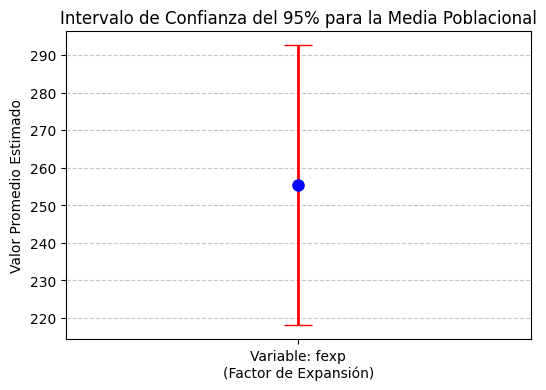

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Importar el dataset regional mediante pandas
# Nota: Usamos sep=";" ya que tu CSV está separado por puntos y comas.
df = pd.read_csv("Dataset_hogares_ambiental_2025.csv", sep=";")

# 2. Seleccionar y limpiar variable cuantitativa estratégica (fexp)
# El dataset original tiene números con múltiples puntos, creamos una función para limpiarlo.
def clean_fexp(val):
    val_str = str(val).strip()
    if val_str.count('.') > 1:
        parts = val_str.split('.')
        val_str = "".join(parts[:-1]) + "." + parts[-1]
    try:
        return float(val_str)
    except:
        return np.nan

df['fexp_clean'] = df['fexp'].apply(clean_fexp)
data_poblacion = df['fexp_clean'].dropna()

# Extraer una muestra aleatoria de 150 hogares
np.random.seed(42)
n_muestra = 150
muestra_regional = data_poblacion.sample(n=n_muestra)

# 3. Determinar distribución basada en el tamaño de n
# Como n (150) >= 30, el Teorema del Límite Central nos permite utilizar la Distribución Normal (Z).
media_muestral = np.mean(muestra_regional)
desv_estandar = np.std(muestra_regional, ddof=1)
error_estandar = desv_estandar / np.sqrt(n_muestra)

# 4. Calcular y reportar el Intervalo de Confianza al 95%
nivel_confianza = 0.95
ic_inf, ic_sup = norm.interval(confidence=nivel_confianza, loc=media_muestral, scale=error_estandar)
margen_error = (ic_sup - ic_inf) / 2

print("--- Hito del Proyecto: Estimación de la Realidad Regional ---")
print(f"Tamaño de muestra (n): {n_muestra} (Distribución Z)")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f}")
print(f"Margen de Error: ±{margen_error:.2f}")
print(f"Intervalo de Confianza (95%): [{ic_inf:.2f}, {ic_sup:.2f}]")

# 5. Utilizar matplotlib para graficar (plt.errorbar)
plt.figure(figsize=(6, 4))
plt.errorbar(x=1, y=media_muestral, yerr=margen_error, fmt='o', color='blue',
             ecolor='red', capsize=10, elinewidth=2, markersize=8)

plt.xticks([1], ['Variable: fexp\n(Factor de Expansión)'])
plt.ylabel('Valor Promedio Estimado')
plt.title('Intervalo de Confianza del 95% para la Media Poblacional')
plt.xlim(0.5, 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Tarea 4: ABI - El Impacto del Nivel de Confianza (1 - a )**
El bucle iterativo automatiza el cálculo matemático para evidenciar el ensanchamiento intrínseco del margen de error al elevar las exigencias del umbral de certidumbre

--- Análisis de Sensibilidad: Margen de Error ---
Confianza 80% -> Z: 1.282 -> Margen de Error: ±5.24 kWh
Confianza 90% -> Z: 1.645 -> Margen de Error: ±6.72 kWh
Confianza 95% -> Z: 1.960 -> Margen de Error: ±8.01 kWh
Confianza 99% -> Z: 2.576 -> Margen de Error: ±10.53 kWh


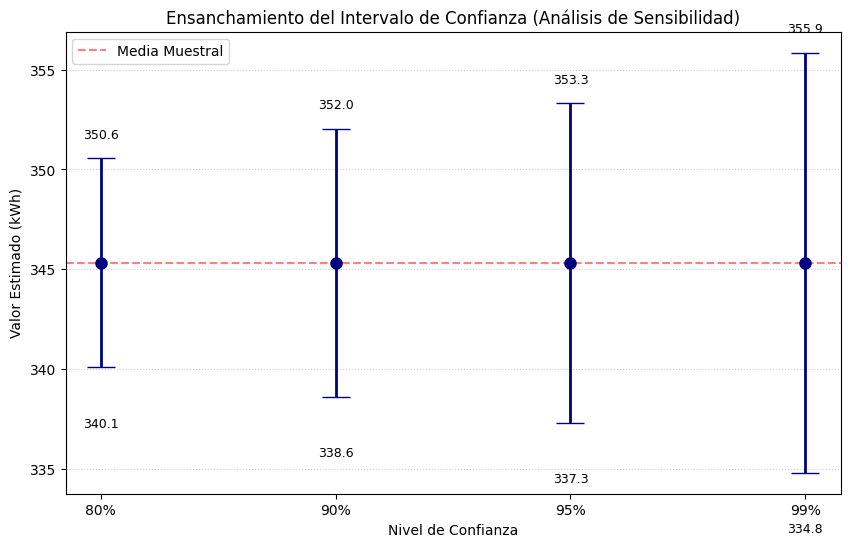

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Datos base
np.random.seed(42)
n = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1)
error_estandar = desv_estandar / np.sqrt(n)

# 2. Análisis de Sensibilidad (Bucle para calcular Margen de Error)
niveles_confianza = [0.80, 0.90, 0.95, 0.99]
margenes_error = []

print("--- Análisis de Sensibilidad: Margen de Error ---")
for nc in niveles_confianza:
    # Calculamos Z crítico: norm.ppf(1 - alpha/2)
    z_critico = norm.ppf(1 - (1 - nc) / 2)
    me = z_critico * error_estandar
    margenes_error.append(me)
    print(f"Confianza {nc*100:.0f}% -> Z: {z_critico:.3f} -> Margen de Error: ±{me:.2f} kWh")

# 3. Graficación profesional con barras de error
plt.figure(figsize=(10, 6))

# Usamos errorbar para mostrar la media y el rango de error
plt.errorbar(x=[str(int(nc*100))+"%" for nc in niveles_confianza],
             y=[media_muestral]*len(niveles_confianza),
             yerr=margenes_error,
             fmt='o', capsize=10, elinewidth=2, color='navy', markersize=8)

# Añadir los valores numéricos encima de las barras
for i, me in enumerate(margenes_error):
    plt.text(i, media_muestral + me + 1, f'{media_muestral+me:.1f}', ha='center', fontsize=9)
    plt.text(i, media_muestral - me - 3, f'{media_muestral-me:.1f}', ha='center', fontsize=9)

plt.axhline(media_muestral, color='red', linestyle='--', alpha=0.5, label='Media Muestral')
plt.title('Ensanchamiento del Intervalo de Confianza (Análisis de Sensibilidad)')
plt.xlabel('Nivel de Confianza')
plt.ylabel('Valor Estimado (kWh)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

## **Argumentación teórica**
A medida que exigimos mayor nivel de confianza (certeza), el intervalo se ensancha incrementando el margen de error. En la toma de decisiones e ingeniería, el nivel del 95% se establece como el estándar de la industria porque equilibra de manera óptima un alto grado de certeza sin penalizar excesivamente la precisión estadística. Exigir un 99% expande la frontera de los valores críticos de la distribución para atrapar el parámetro poblacional, resultando en un intervalo tan amplio que pierde su capacidad práctica y utilidad analítica para optimizar recursos reales.